# M1M9 GARCH-low／constant-high：Out-of-Time Adaptive EnbPI

這份 notebook 不覆蓋原本的 M1M9 實驗。除了資料生成方式以外，OOT cross-fit、causal KF、ARIMA+ANN bootstrap hybrid、adaptive residual-window selection、final-test sequential EnbPI、設定與評估流程都與 `KF_m1m9_OutOfTime_Adaptive_EnbPI.ipynb` 相同。

新的 DGP 保留 M1 與 M9 conditional mean。Low innovation variance 改為擾動明顯的 GARCH(1,1)；high innovation standard deviation 固定為 1，不再由 low state 或 low variance 決定。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

meeting_root = None
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / 'src' / 'kf_forecasting').exists():
        meeting_root = candidate
        break
if meeting_root is None:
    raise RuntimeError('找不到 meeting/src/kf_forecasting，請從 project/meeting 或其子目錄啟動 notebook。')
sys.path.insert(0, str(meeting_root / 'src'))

from kf_forecasting.models.kf_enbpi import (
    EnbPIConfig,
    plot_monte_carlo_forecast_diagnostics,
    plot_monte_carlo_summary,
    plot_result,
    simulate_m1_m9_garch_low_constant_high_variance_data,
    M1M9_GARCH_LOW_OMEGA,
    M1M9_GARCH_LOW_ALPHA,
    M1M9_GARCH_LOW_BETA,
)
from kf_forecasting.models.kf_out_of_time_enbpi import (
    OutOfTimeEnbPIConfig,
    monte_carlo_out_of_time,
    plot_window_selection,
    simulate_and_run_out_of_time,
)

pd.set_option('display.precision', 4)

## 新資料生成方程式

Low conditional mean 為 M1：

$$L_t=0.6L_{t-1}+u_t,\qquad u_t=\sqrt{h_t}z_t,\qquad z_t\sim N(0,1),$$

條件變異數為

$$h_t=0.50+0.15u_{t-1}^2+0.80h_{t-1}.$$

High conditional mean 為 M9，innovation variance 固定：

$$H_t=0.8H_{t-1}-\frac{0.8H_{t-1}}{1+\exp(-10H_{t-1})}+v_t,\qquad v_t\sim N(0,1).$$

最後 $Y_t=L_t+H_t+\eta_t$，其中 $\eta_t\sim N(0,0.15^2)$。

## 設定

以下設定刻意與原 M1M9 OOT notebook 相同，確保比較時唯一結構差異是 DGP。

In [2]:
base_config = EnbPIConfig(
    window_size=15,
    alpha=0.05,
    n_bootstrap=30,
    block_length=None,
    batch_size=1,
    beta_grid_size=101,
    oob_bias_correction=True,
    oob_bias_correction_mode='combined',
    arima_order=None,
    arima_max_p=4,
    arima_max_q=4,
    arima_max_iter=500,
    ann_hidden_layers=(32, 16),
    ann_max_iter=500,
    ann_alpha=1e-4,
    ann_learning_rate_init=1e-3,
    ann_target_standardization=True,
    ann_early_stopping=False,
    ann_rolling_validation=True,
    ann_rolling_splits=3,
    ann_validation_fraction=0.10,
    ann_iteration_candidates=(125, 250, 500),
    ann_tol=1e-3,
    random_state=1234,
)

config = OutOfTimeEnbPIConfig(
    base=base_config,
    initial_train_fraction=0.50,
    n_crossfit_blocks=4,
    residual_window_candidates=(100, 200, 300, 400, None),
    window_validation_fraction=0.40,
    min_window_history=40,
)

model_key = 'm1m9_garch_low_constant_high_variance'
train_size = 650
horizon = 200
data_seed = 2026

## 單次實驗

In [3]:
out_of_time_result = simulate_and_run_out_of_time(
    model_key,
    train_size=train_size,
    horizon=horizon,
    config=config,
    data_seed=data_seed,
)
result = out_of_time_result.forecast

final_summary, component_summary, calibration_summary = out_of_time_result.summary_tables()
display(final_summary)
display(component_summary)
display(calibration_summary)

,model,data_seed,ensemble_seed,arima_order,mse,rmse,coverage_percent,mean_width,mean_beta,mean_bias_correction,bias_correction_mode,ann_selected_max_iter_mean,ann_rolling_validation_mse,ann_nonconverged_models,arima_retry_count,arima_nonconverged_fits,elapsed_seconds
0,M1M9_GARCH_LOW_CONSTANT_HIGH_VARIANCE,2026,1234,"(2, 0, 0)",8.5887,2.9307,93.5,11.5606,0.0228,-0.4226,combined,125.0,8.2302,30,0,0,247.0073


,component,reference,mse,rmse,coverage_percent,enbpi_mean_width,mean_beta,mean_bias_correction
0,low_arima,kalman_low,0.4834,0.6952,93.5,2.8235,0.0177,0.0
1,high_ann_mse,kalman_high,5.6862,2.3846,95.5,9.3253,0.0223,0.0
2,low_arima,true_low,10.6277,3.2600,34.0,2.8235,0.0177,0.0
3,high_ann_mse,true_high,5.7190,2.3914,96.0,9.3253,0.0223,0.0


,calibration_method,selected_residual_window,crossfit_residual_count,crossfit_fold_count,initial_test_pool_size,arima_retry_count,arima_nonconverged_fits
0,rolling_origin_block_crossfit,400.0,325.0,4.0,325.0,0.0,0.0


## DGP 波動診斷

這一格只檢查新資料確實符合設計，不參與模型訓練。Low 的真實 innovation 可由 $u_t=L_t-0.6L_{t-1}$ 還原，再依同一 GARCH recursion 重建 $h_t$；high innovation 則扣除 M9 conditional mean。

,model,low_innovation_variance_mean,low_innovation_variance_min,low_innovation_variance_max,low_variance_max_to_min_ratio,low_innovation_empirical_std,high_innovation_empirical_std,corr_abs_low_lag_high_innovation_squared
0,m1m9_garch_low_constant_high_variance,7.6502,1.0345,96.9292,93.6944,2.8572,1.0251,-0.0155


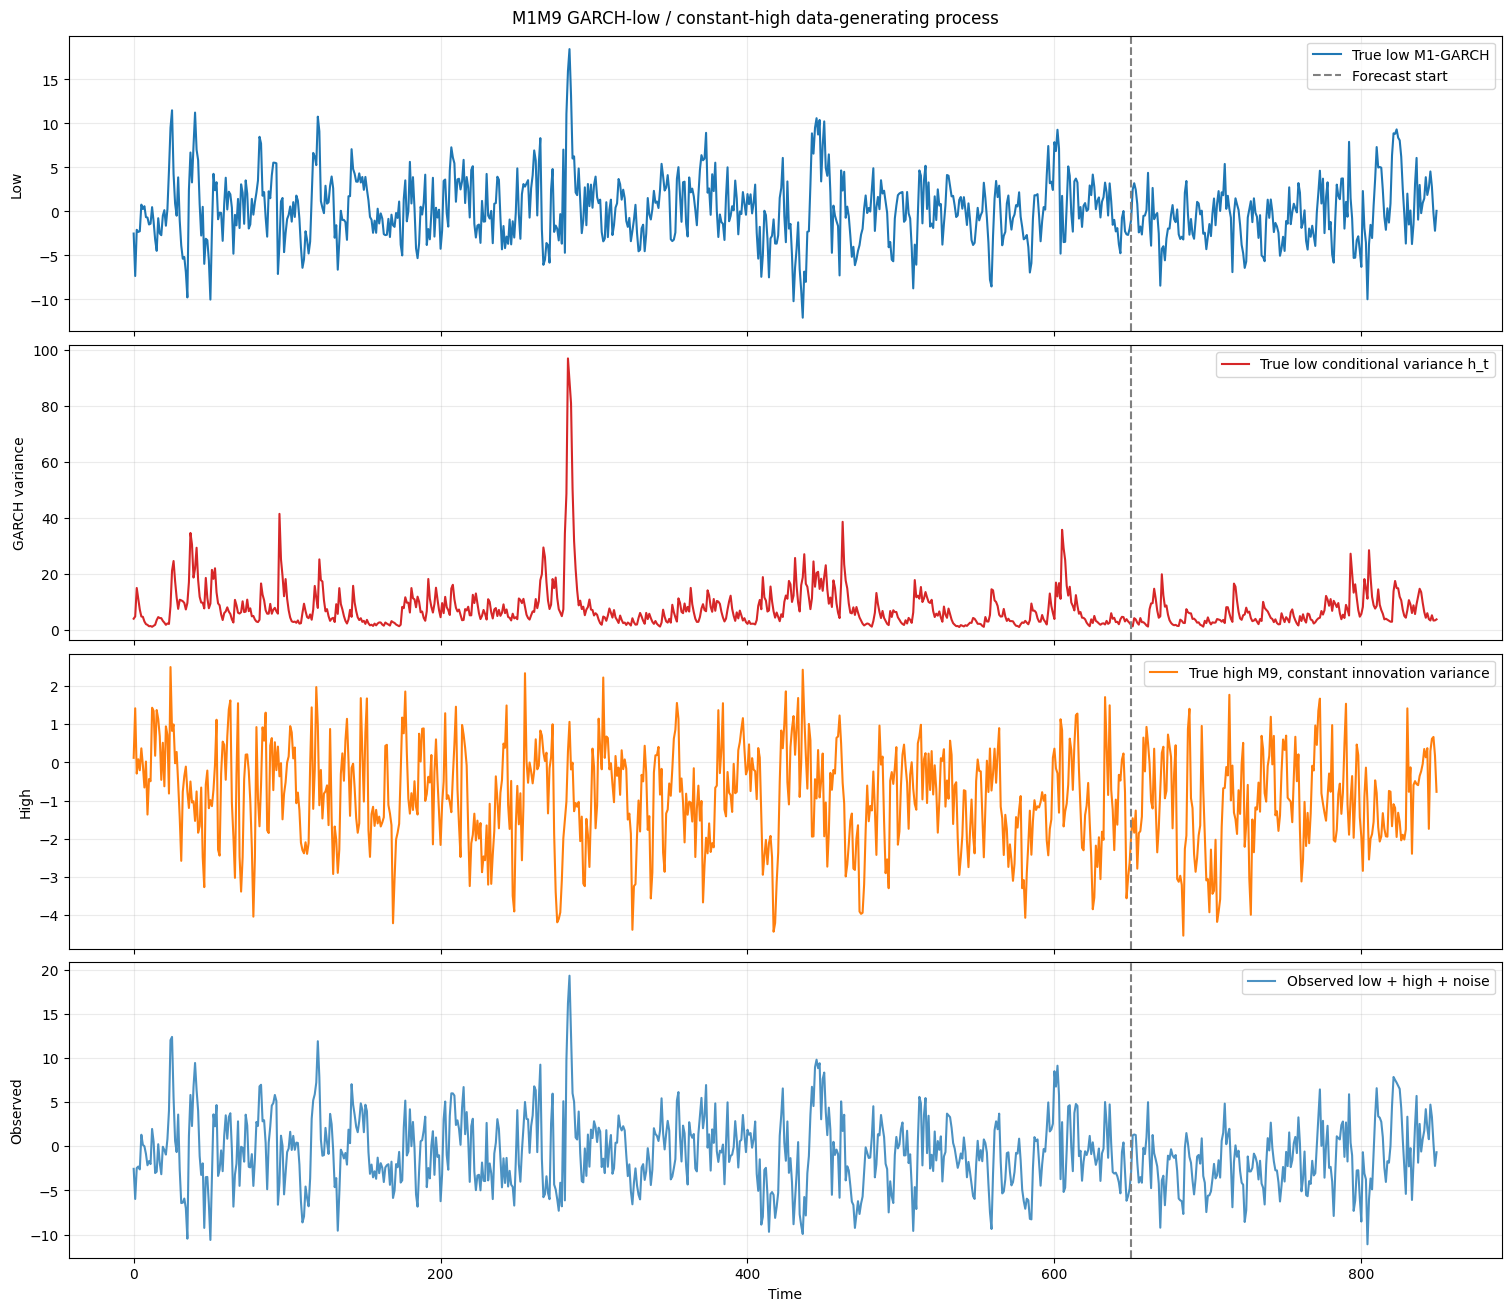

In [4]:
true_low = np.asarray(result.true_low, dtype=float)
true_high = np.asarray(result.true_high, dtype=float)
n_steps = len(true_low)

low_innovation = np.empty(n_steps)
low_innovation[0] = true_low[0]
low_innovation[1:] = true_low[1:] - 0.6 * true_low[:-1]
low_variance = np.empty(n_steps)
low_variance[0] = M1M9_GARCH_LOW_OMEGA / (1.0 - M1M9_GARCH_LOW_ALPHA - M1M9_GARCH_LOW_BETA)
for t in range(1, n_steps):
    low_variance[t] = (
        M1M9_GARCH_LOW_OMEGA
        + M1M9_GARCH_LOW_ALPHA * low_innovation[t - 1] ** 2
        + M1M9_GARCH_LOW_BETA * low_variance[t - 1]
    )

high_lag = true_high[:-1]
high_gate = 1.0 / (1.0 + np.exp(np.clip(-10.0 * high_lag, -700.0, 700.0)))
high_mean = 0.8 * high_lag - 0.8 * high_lag * high_gate
high_innovation = true_high[1:] - high_mean

dgp_summary = pd.DataFrame([{
    'model': model_key,
    'low_innovation_variance_mean': float(np.mean(low_variance)),
    'low_innovation_variance_min': float(np.min(low_variance)),
    'low_innovation_variance_max': float(np.max(low_variance)),
    'low_variance_max_to_min_ratio': float(np.max(low_variance) / np.min(low_variance)),
    'low_innovation_empirical_std': float(np.std(low_innovation)),
    'high_innovation_empirical_std': float(np.std(high_innovation)),
    'corr_abs_low_lag_high_innovation_squared': float(
        np.corrcoef(np.abs(true_low[:-1]), high_innovation ** 2)[0, 1]
    ),
}])
display(dgp_summary)

fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True, constrained_layout=True)
fig.suptitle('M1M9 GARCH-low / constant-high data-generating process')
axes[0].plot(true_low, label='True low M1-GARCH')
axes[0].axvline(train_size, color='gray', linestyle='--', label='Forecast start')
axes[0].set_ylabel('Low')
axes[0].legend(loc='best')
axes[1].plot(low_variance, color='tab:red', label='True low conditional variance h_t')
axes[1].axvline(train_size, color='gray', linestyle='--')
axes[1].set_ylabel('GARCH variance')
axes[1].legend(loc='best')
axes[2].plot(true_high, color='tab:orange', label='True high M9, constant innovation variance')
axes[2].axvline(train_size, color='gray', linestyle='--')
axes[2].set_ylabel('High')
axes[2].legend(loc='best')
axes[3].plot(result.observed, alpha=0.8, label='Observed low + high + noise')
axes[3].axvline(train_size, color='gray', linestyle='--')
axes[3].set_ylabel('Observed')
axes[3].set_xlabel('Time')
axes[3].legend(loc='best')
for axis in axes:
    axis.grid(alpha=0.25)
plt.show()

## Cross-fit audit

這裡確認每個 validation block 的模型只使用該 block 以前的資料，且 final residual 恆等於 low residual 加 high residual。

In [5]:
display(out_of_time_result.fold_summary)
display(out_of_time_result.crossfit_predictions.head())

assert (
    out_of_time_result.crossfit_predictions['fit_end_exclusive']
    <= out_of_time_result.crossfit_predictions['time']
).all()
assert (
    out_of_time_result.crossfit_predictions['final_residual']
    - out_of_time_result.crossfit_predictions['low_residual']
    - out_of_time_result.crossfit_predictions['high_residual']
).abs().max() < 1e-10

,fold,train_start,train_stop_exclusive,validation_start,validation_stop_exclusive,n_train_observations,n_validation_observations,arima_order,ann_selected_max_iter_mean,arima_retry_count,arima_nonconverged_fits,random_state
0,1,0,325,325,407,325,82,"(2, 0, 0)",129.1667,0,0,1923223294
1,2,0,407,407,488,407,81,"(2, 0, 0)",137.5000,0,0,2093418128
2,3,0,488,488,569,488,81,"(2, 0, 0)",137.5000,0,0,1196192930
3,4,0,569,569,650,569,81,"(2, 0, 0)",125.0000,0,0,949551623


,fold,fit_end_exclusive,time,truth,final_point,low_reference,low_point,high_reference,high_point,final_residual,low_residual,high_residual
0,1,325,325,-6.5717,-2.5258,-2.3922,-1.0976,-4.1795,-1.4282,-4.0459,-1.2945,-2.7513
1,1,325,326,-4.1312,-3.5503,-2.7400,-1.9309,-1.3913,-1.6194,-0.5809,-0.8091,0.2282
2,1,325,327,-2.5013,-2.4830,-2.6922,-2.2146,0.1909,-0.2684,-0.0183,-0.4776,0.4593
3,1,325,328,-4.4228,-1.1747,-3.0384,-2.1799,-1.3845,1.0052,-3.2481,-0.8584,-2.3897
4,1,325,329,-5.4895,-1.8256,-3.5286,-2.4528,-1.9610,0.6273,-3.6640,-1.0757,-2.5882


## Training-only adaptive residual-window 選擇

,window,window_value,mean_interval_score,coverage,mean_width,n_validation_residuals,validation_start_position,selected
0,400,400.0,14.0418,0.9538,11.8207,130,195,True
1,all,NaN,14.0418,0.9538,11.8207,130,195,False
2,300,300.0,14.0579,0.9538,11.8368,130,195,False
3,200,200.0,15.5624,0.9385,11.9076,130,195,False
4,100,100.0,15.7216,0.9154,10.6029,130,195,False


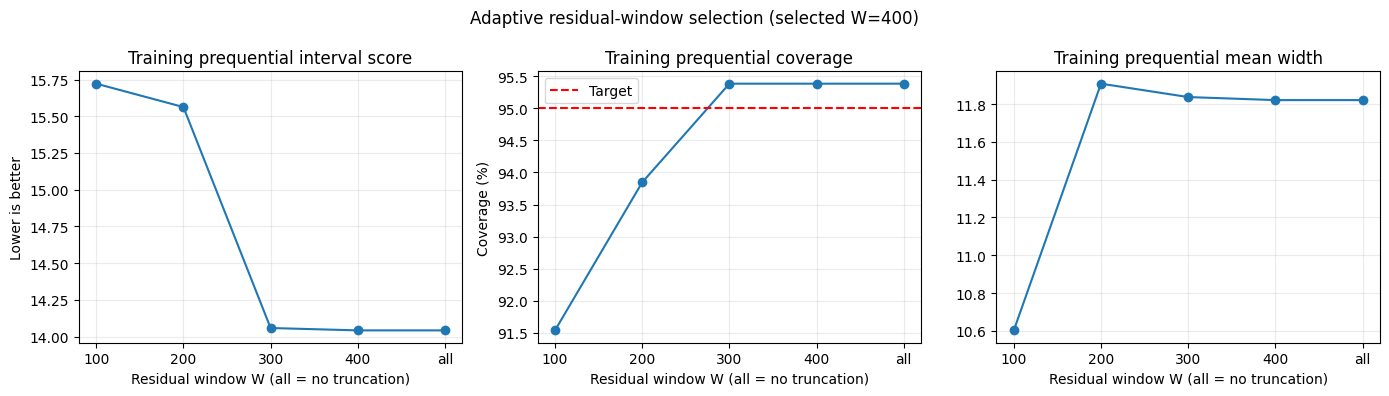

In [6]:
display(out_of_time_result.window_selection)
plot_window_selection(out_of_time_result)
plt.show()

## 最終預測圖

沿用原 M1M9 OOT 五圖；第三、四、五張區間都由 out-of-time calibration residuals 建立。

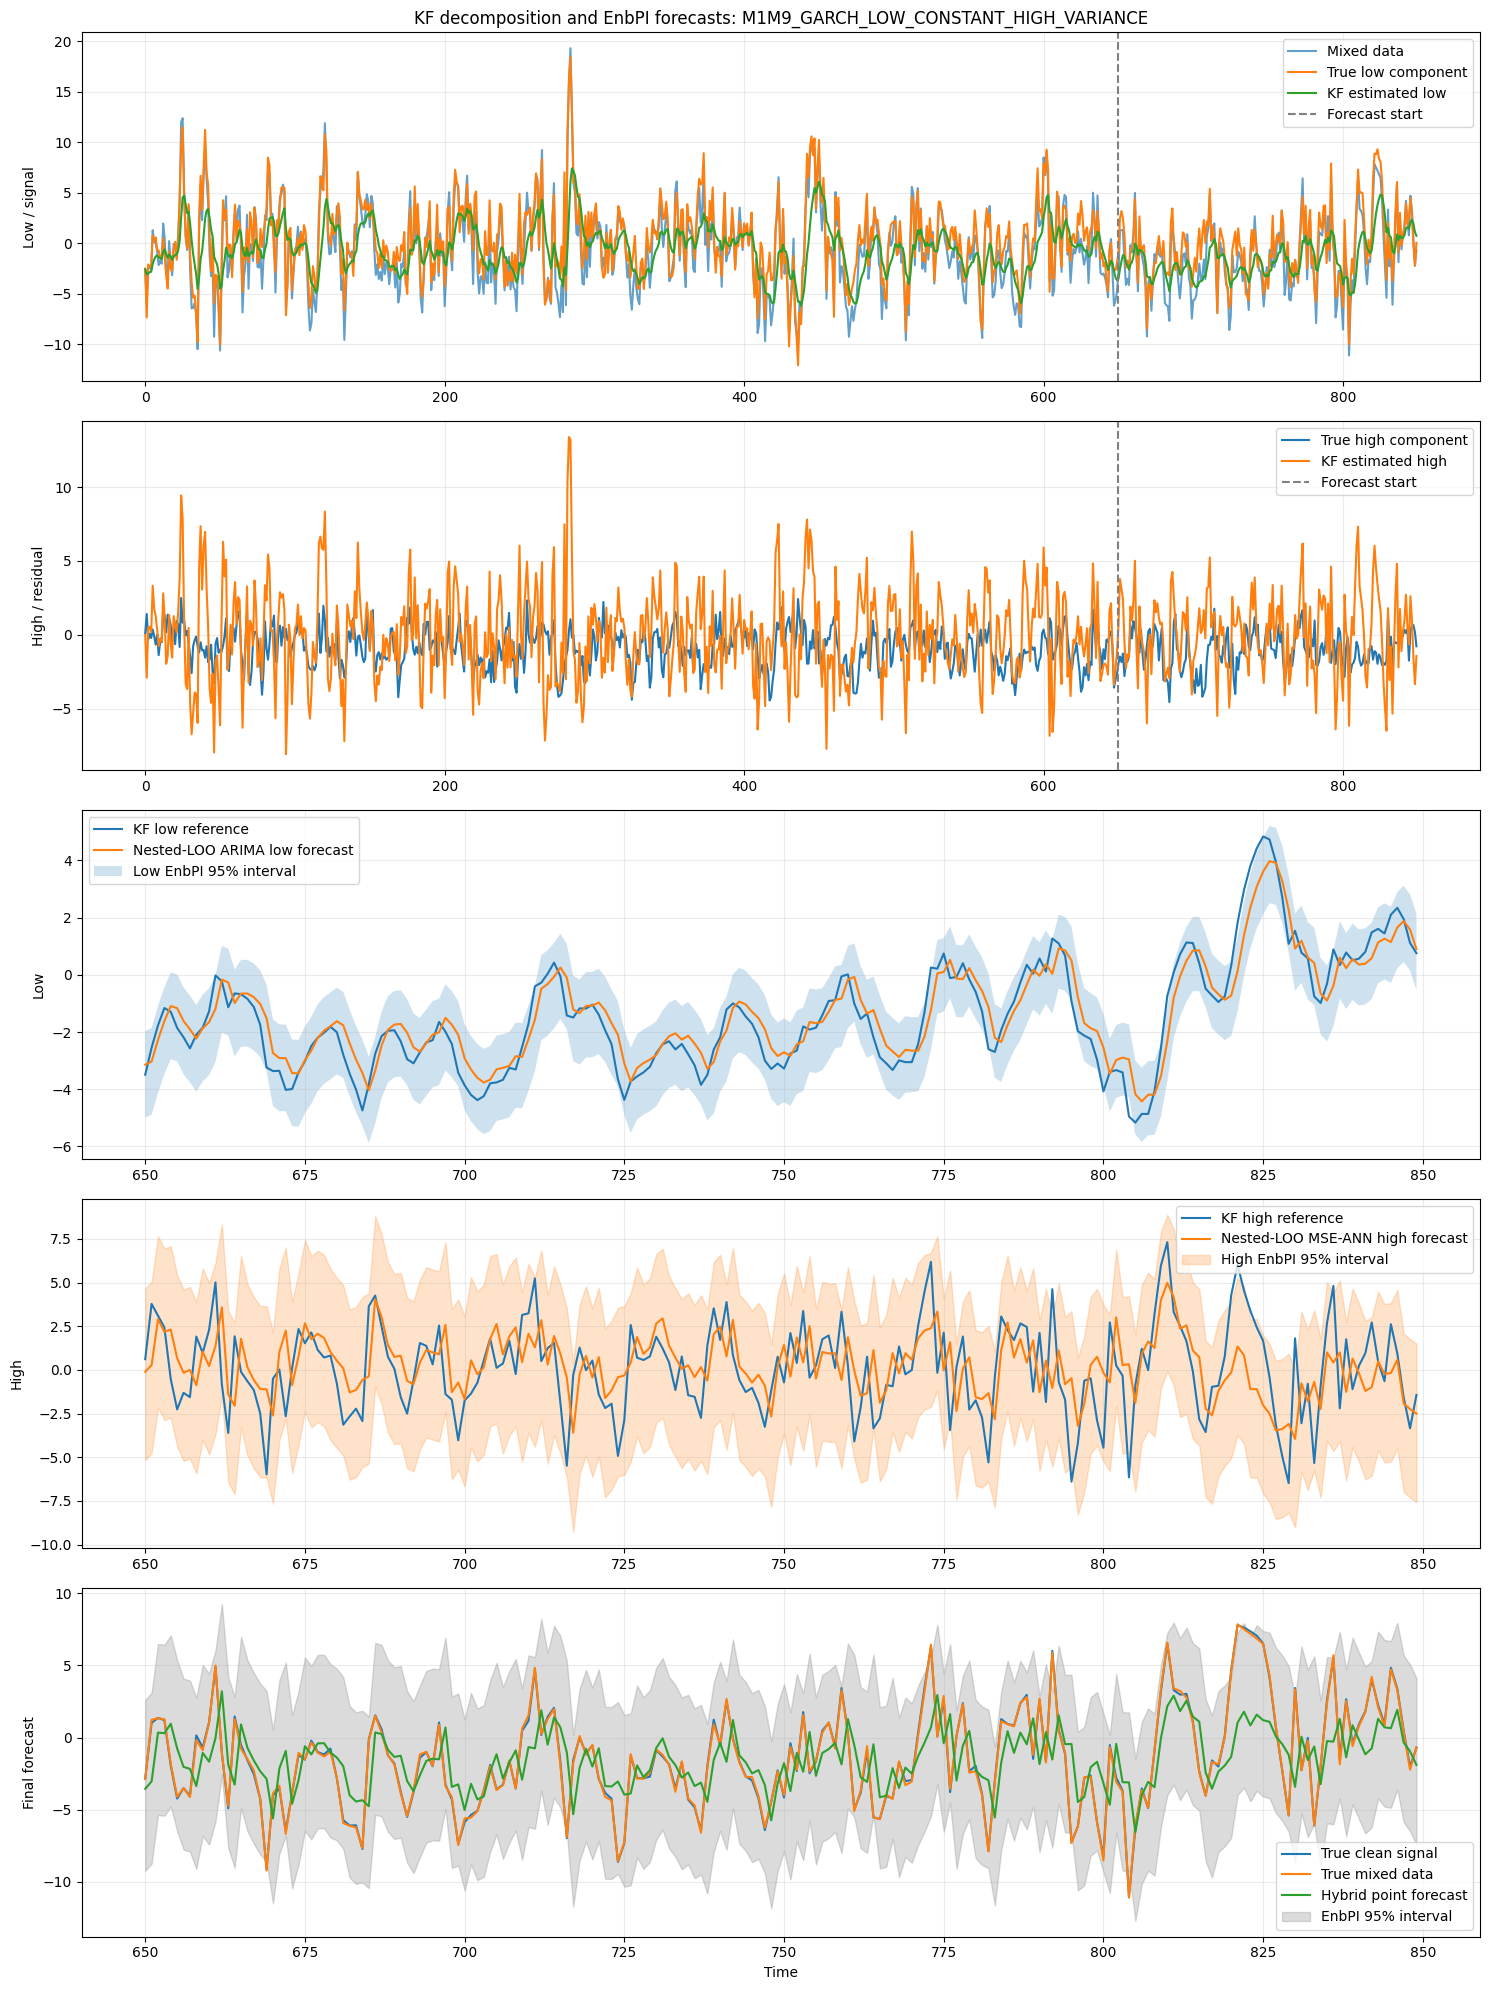

In [7]:
plot_result(result)
plt.show()

## True-component error cancellation 驗證

這裡直接檢查 true-low 與 true-high 的預測誤差是否反向，並比較成分區間、成分區間直接相加，以及 combined-residual EnbPI 的 coverage。若誤差相關係數為負、異號比例偏高，而且 low 未涵蓋時 final 仍常被涵蓋，才有數值證據支持「成分誤差在合併時抵銷」。

In [ ]:
t = np.asarray(result.test_times, dtype=int)
true_low_test = np.asarray(result.true_low, dtype=float)[t]
true_high_test = np.asarray(result.true_high, dtype=float)[t]
observed_test = np.asarray(result.observed, dtype=float)[t]

# 統一採用 truth - prediction；正值代表低估、負值代表高估。
low_true_error = true_low_test - np.asarray(result.low_point, dtype=float)
high_true_error = true_high_test - np.asarray(result.high_point, dtype=float)
observation_noise = observed_test - true_low_test - true_high_test
final_error = np.asarray(result.truth, dtype=float) - np.asarray(result.point, dtype=float)
point_recombination_adjustment = (
    np.asarray(result.point, dtype=float)
    - np.asarray(result.low_point, dtype=float)
    - np.asarray(result.high_point, dtype=float)
)
component_sum_error = low_true_error + high_true_error
reconstructed_final_error = (
    component_sum_error + observation_noise - point_recombination_adjustment
)
identity_max_abs_error = float(
    np.max(np.abs(final_error - reconstructed_final_error))
)

error_corr = float(np.corrcoef(low_true_error, high_true_error)[0, 1])
error_cov = float(np.cov(low_true_error, high_true_error, ddof=0)[0, 1])
opposite_sign_rate = float(np.mean(low_true_error * high_true_error < 0.0))
variance_cross_term = 2.0 * error_cov

low_true_covered = (true_low_test >= result.low_lower) & (true_low_test <= result.low_upper)
high_true_covered = (true_high_test >= result.high_lower) & (true_high_test <= result.high_upper)
final_covered = (result.truth >= result.lower) & (result.truth <= result.upper)
summed_lower = np.asarray(result.low_lower) + np.asarray(result.high_lower)
summed_upper = np.asarray(result.low_upper) + np.asarray(result.high_upper)
clean_truth = true_low_test + true_high_test
summed_component_coverage_clean = float(
    np.mean((clean_truth >= summed_lower) & (clean_truth <= summed_upper))
)
low_miss = ~low_true_covered
final_covered_given_low_miss = (
    float(np.mean(final_covered[low_miss])) if np.any(low_miss) else np.nan
)

cancellation_summary = pd.DataFrame({
    'metric': [
        'corr(low true error, high true error)',
        'cov(low true error, high true error)',
        '2 x covariance contribution to Var(e_low + e_high)',
        'opposite-sign error rate',
        'low true-error RMSE',
        'high true-error RMSE',
        'clean component-sum error RMSE',
        'final observed-error RMSE',
        'algebra identity max absolute error',
    ],
    'value': [
        error_corr,
        error_cov,
        variance_cross_term,
        opposite_sign_rate,
        np.sqrt(np.mean(low_true_error**2)),
        np.sqrt(np.mean(high_true_error**2)),
        np.sqrt(np.mean(component_sum_error**2)),
        np.sqrt(np.mean(final_error**2)),
        identity_max_abs_error,
    ],
})
coverage_diagnostic = pd.DataFrame({
    'metric': [
        'low true-component coverage',
        'high true-component coverage',
        'both true components covered',
        'summed component interval coverage (clean L+H)',
        'direct combined EnbPI coverage (observed Y)',
        'P(final covered | low not covered)',
        'mean low interval width',
        'mean high interval width',
        'mean summed component width',
        'mean direct final width',
    ],
    'value': [
        np.mean(low_true_covered),
        np.mean(high_true_covered),
        np.mean(low_true_covered & high_true_covered),
        summed_component_coverage_clean,
        np.mean(final_covered),
        final_covered_given_low_miss,
        np.mean(result.low_upper - result.low_lower),
        np.mean(result.high_upper - result.high_lower),
        np.mean(summed_upper - summed_lower),
        np.mean(result.upper - result.lower),
    ],
})

display(cancellation_summary)
display(coverage_diagnostic)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(low_true_error, high_true_error, alpha=0.55, s=24)
xlim = np.asarray(axes[0].get_xlim())
axes[0].plot(xlim, -xlim, '--', color='black', linewidth=1.2, label=r'$e_H=-e_L$')
coef = np.polyfit(low_true_error, high_true_error, 1)
axes[0].plot(xlim, coef[0] * xlim + coef[1], color='red', label=f'OLS slope={coef[0]:.3f}')
axes[0].axhline(0.0, color='grey', linewidth=0.8)
axes[0].axvline(0.0, color='grey', linewidth=0.8)
axes[0].set_xlabel(r'True-low error $L_t-\hat L_t$')
axes[0].set_ylabel(r'True-high error $H_t-\hat H_t$')
axes[0].set_title(f'Component-error dependence: corr={error_corr:.3f}')
axes[0].legend()

axes[1].plot(t, low_true_error, alpha=0.65, label='Low true error')
axes[1].plot(t, high_true_error, alpha=0.65, label='High true error')
axes[1].plot(t, component_sum_error, color='black', linewidth=1.4, label='Low + high error')
axes[1].axhline(0.0, color='grey', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Truth minus prediction')
axes[1].set_title(f'Error cancellation; opposite signs={100*opposite_sign_rate:.1f}%')
axes[1].legend()
plt.tight_layout()
plt.show()

## Monte Carlo

保留與原 M1M9 OOT notebook 相同的 20-run Monte Carlo。若只想先確認單次結果，可把 `RUN_MONTE_CARLO` 改成 `False`。

In [8]:
RUN_MONTE_CARLO = True
N_RUNS = 20

if RUN_MONTE_CARLO:
    mc_runs, mc_summary, mc_results = monte_carlo_out_of_time(
        model_key,
        n_runs=N_RUNS,
        train_size=train_size,
        horizon=horizon,
        config=config,
        seed=2026,
    )
    display(mc_runs)
    display(mc_summary)

,run,data_seed,mse,rmse,coverage,coverage_percent,mean_width,median_width,low_kf_mse,low_kf_rmse,...,low_true_rmse,low_true_coverage,high_true_mse,high_true_rmse,high_true_coverage,calibration_method,selected_residual_window,crossfit_residual_count,crossfit_fold_count,initial_test_pool_size
0,1,479243620,9.3618,3.0597,0.925,92.5,11.1168,11.1713,0.5685,0.7540,...,3.2246,0.305,4.0919,2.0228,0.965,rolling_origin_block_crossfit,200.0,325.0,4.0,200.0
1,2,454024514,12.6225,3.5528,0.910,91.0,11.9261,11.6214,0.8340,0.9132,...,3.9914,0.360,4.9393,2.2225,0.950,rolling_origin_block_crossfit,200.0,325.0,4.0,200.0
2,3,1818751028,8.2624,2.8744,0.980,98.0,15.1963,15.5605,0.4059,0.6371,...,3.0648,0.425,2.7254,1.6509,1.000,rolling_origin_block_crossfit,300.0,325.0,4.0,300.0
3,4,2288458700,10.8071,3.2874,0.945,94.5,12.5107,12.5340,0.5700,0.7550,...,3.6506,0.345,5.0203,2.2406,0.935,rolling_origin_block_crossfit,200.0,325.0,4.0,200.0
4,5,2115331525,13.3451,3.6531,0.910,91.0,12.5544,12.6925,0.7479,0.8648,...,3.8106,0.325,4.3022,2.0742,0.970,rolling_origin_block_crossfit,200.0,325.0,4.0,200.0
5,6,2666256175,13.3659,3.6559,0.910,91.0,12.2817,12.4158,0.8697,0.9326,...,3.5888,0.355,6.1736,2.4847,0.950,rolling_origin_block_crossfit,100.0,325.0,4.0,100.0
6,7,975381835,22.6993,4.7644,0.870,87.0,14.1747,13.8848,1.3268,1.1519,...,5.1834,0.300,10.1263,3.1822,0.945,rolling_origin_block_crossfit,300.0,325.0,4.0,300.0
7,8,2535166222,11.0326,3.3215,0.905,90.5,11.9802,11.9138,0.6589,0.8118,...,3.6127,0.335,4.2721,2.0669,0.950,rolling_origin_block_crossfit,100.0,325.0,4.0,100.0
8,9,1079577930,14.7058,3.8348,0.930,93.0,15.4590,15.3082,0.9386,0.9688,...,4.4772,0.325,6.4119,2.5322,0.985,rolling_origin_block_crossfit,400.0,325.0,4.0,325.0
9,10,3715024065,12.9380,3.5969,0.920,92.0,12.7662,12.9925,0.6940,0.8330,...,3.9056,0.295,5.7080,2.3892,0.970,rolling_origin_block_crossfit,300.0,325.0,4.0,300.0


,metric,mean,std
0,ann_nonconverged_models,29.7000,0.7327
1,ann_rolling_validation_mse,11.0533,4.1983
2,ann_selected_max_iter_mean,126.0417,2.2922
3,arima_nonconverged_fits,0.0000,0.0000
4,arima_retry_count,0.1000,0.3078
5,coverage,0.9168,0.0370
6,coverage_percent,91.6750,3.7037
7,crossfit_fold_count,4.0000,0.0000
8,crossfit_residual_count,325.0000,0.0000
9,elapsed_seconds,229.9048,11.6688


## Monte Carlo 圖形

這一格只畫上一格已算好的結果，不重新執行 Monte Carlo。

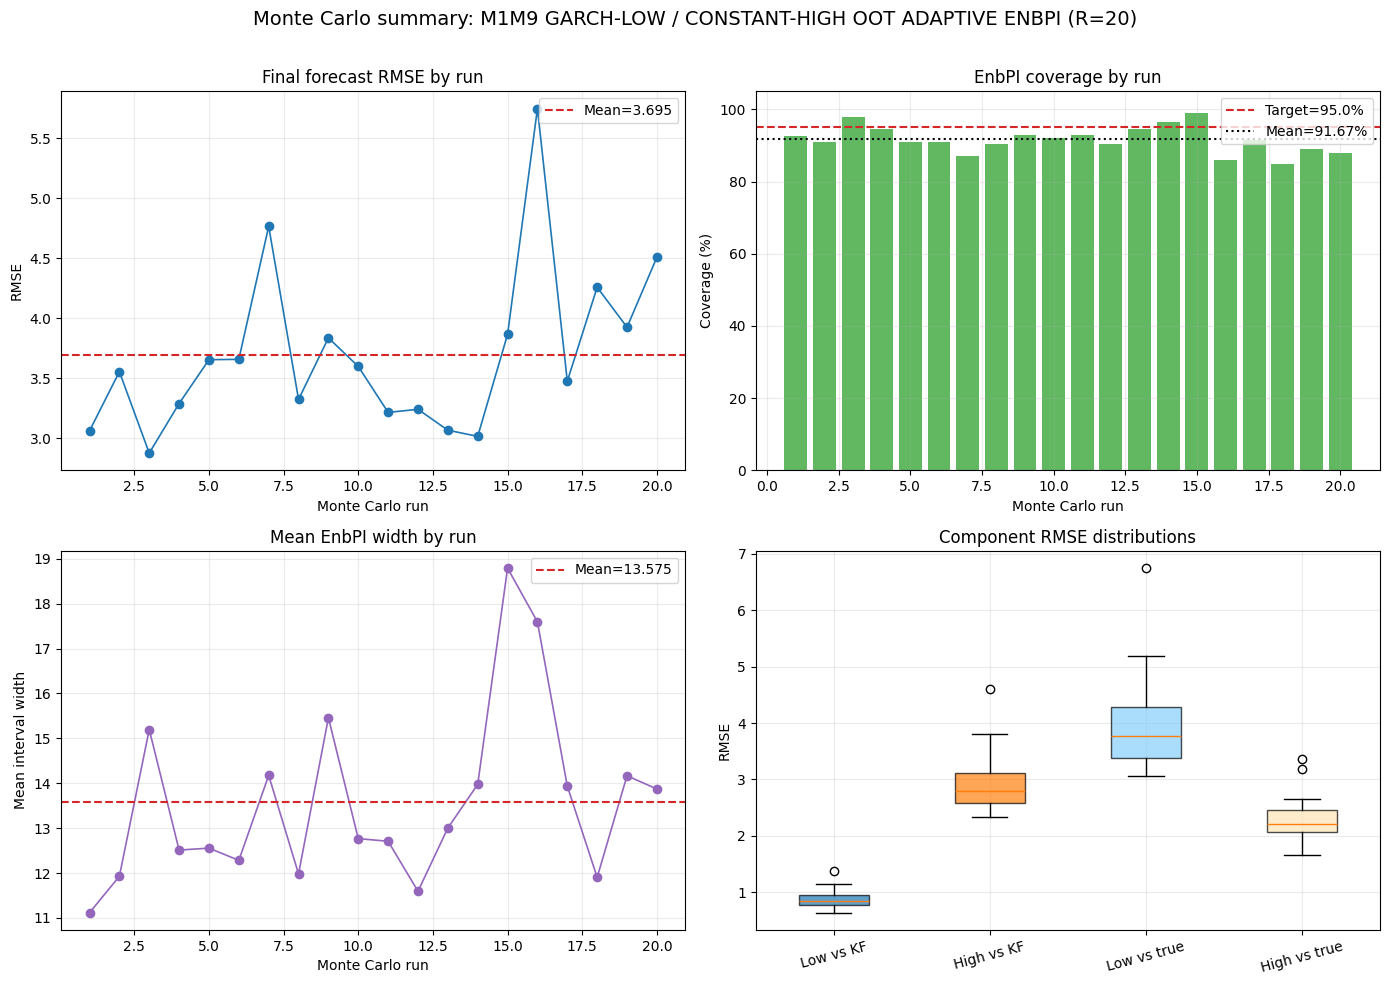

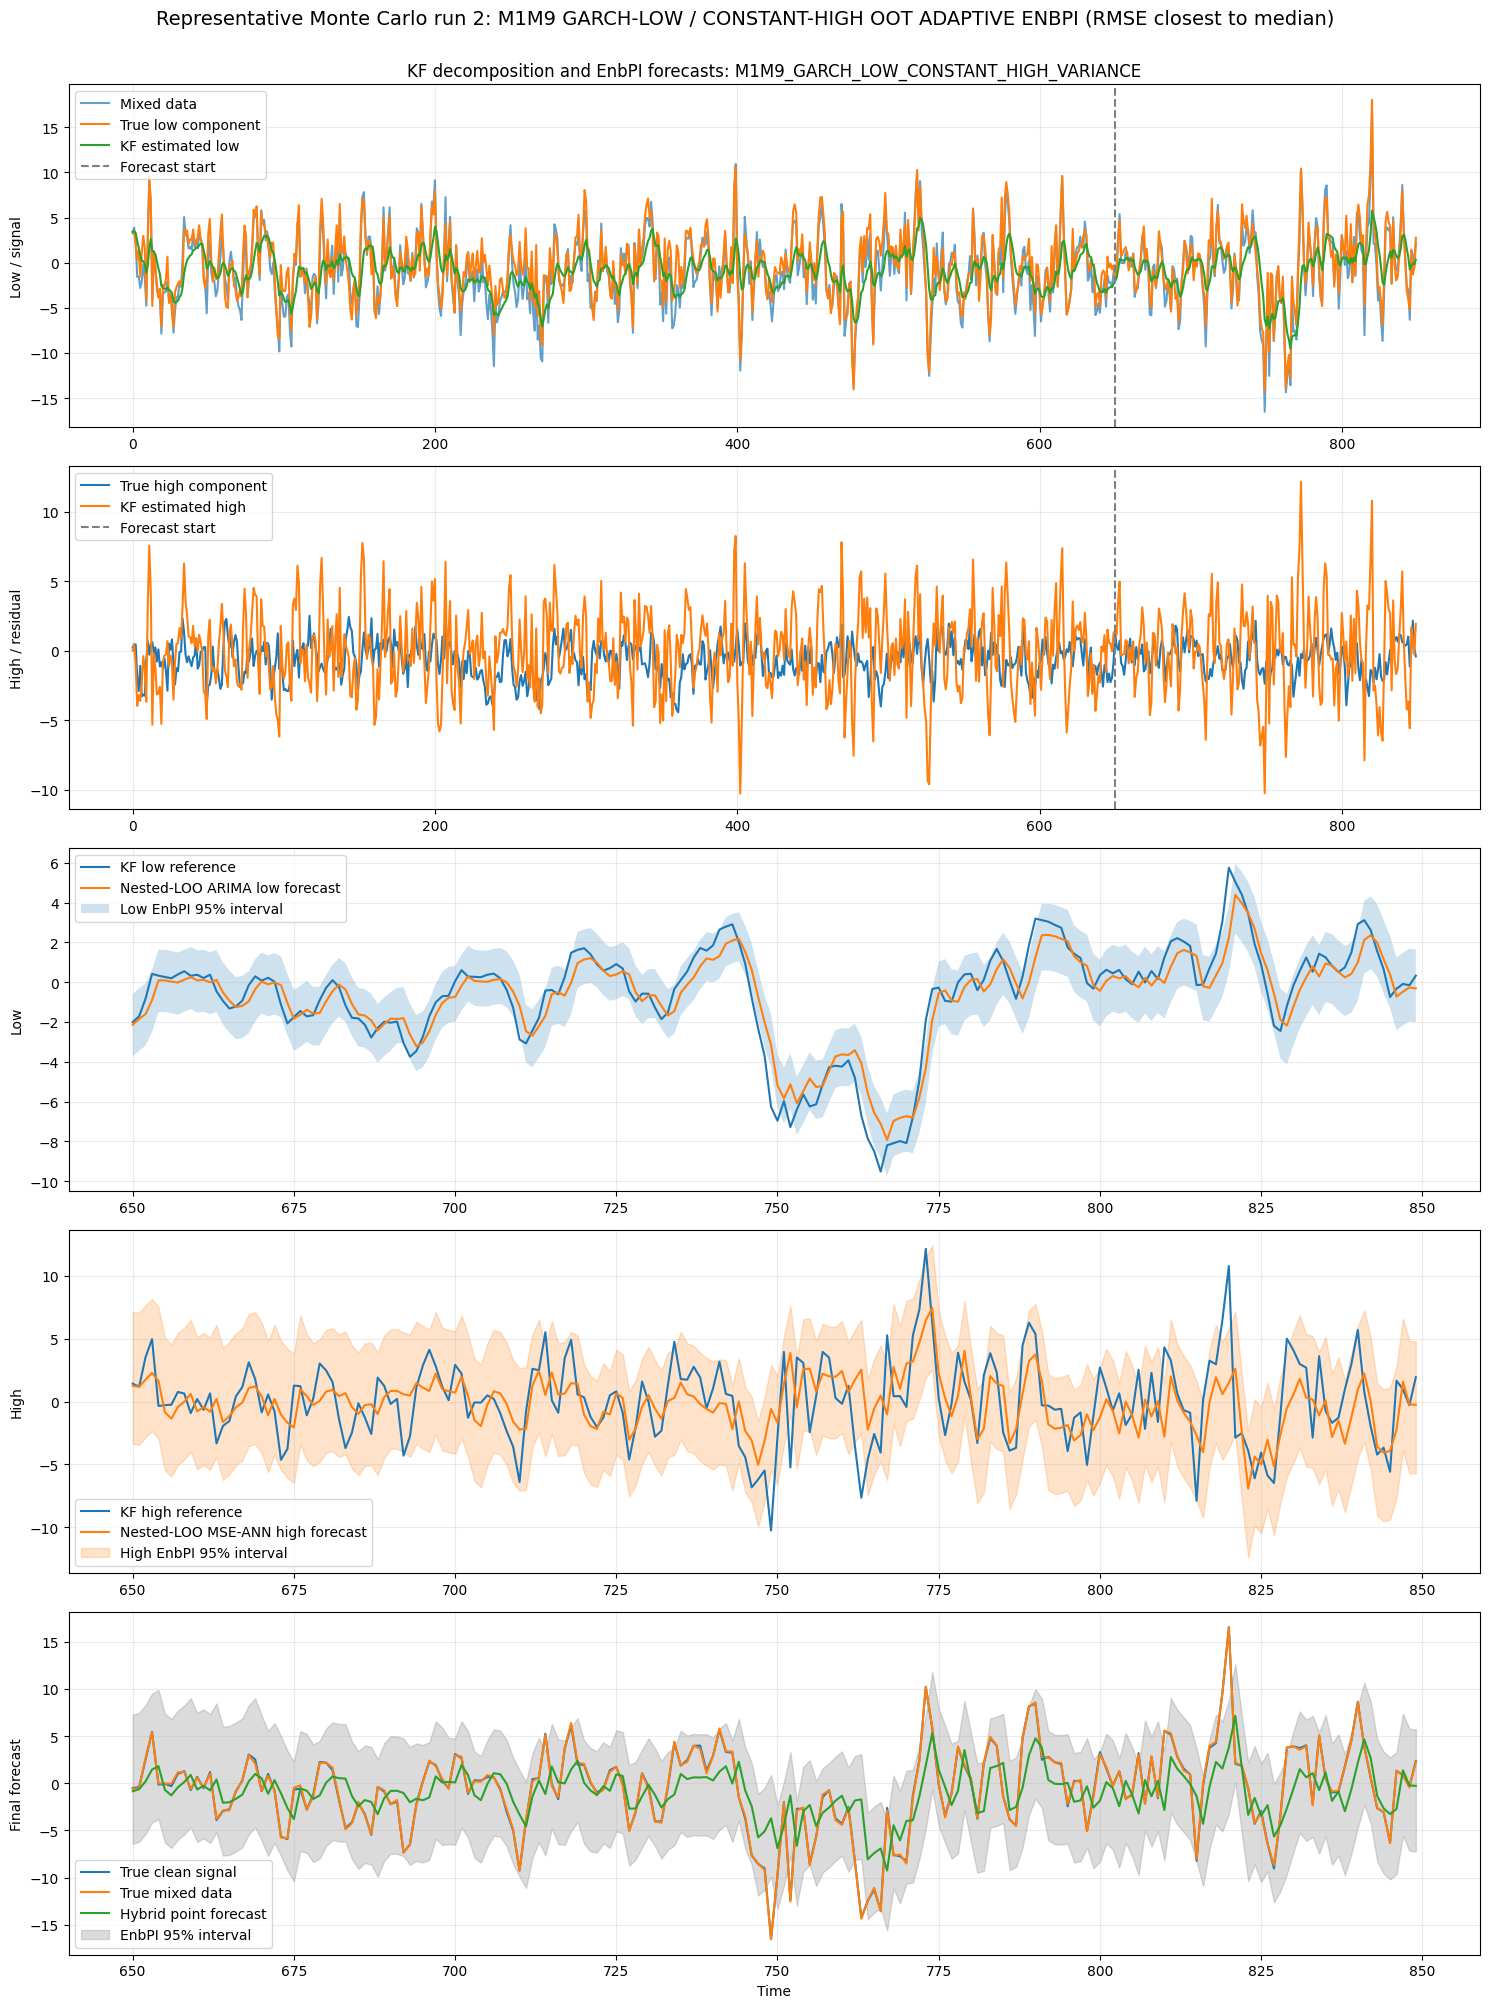

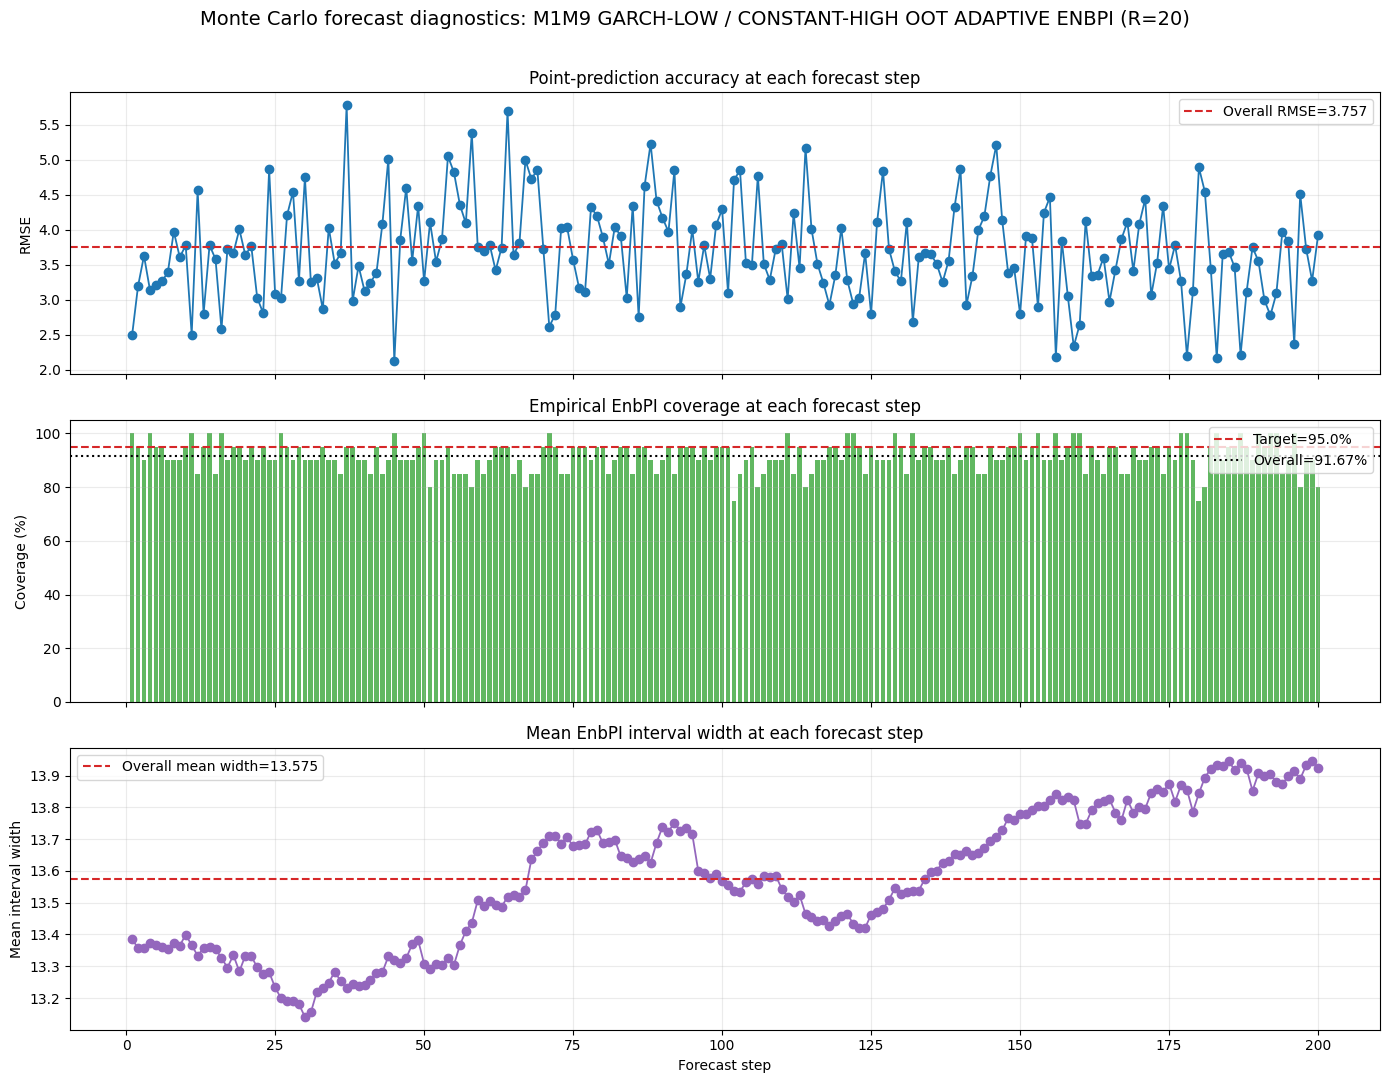

In [9]:
if RUN_MONTE_CARLO:
    mc_forecasts = [item.forecast for item in mc_results]
    model_label = 'M1M9 GARCH-low / constant-high OOT Adaptive EnbPI'
    plot_monte_carlo_summary(
        mc_runs,
        model_name=model_label,
        alpha=config.base.alpha,
    )
    plot_monte_carlo_forecast_diagnostics(
        mc_runs,
        mc_forecasts,
        model_name=model_label,
        alpha=config.base.alpha,
    )
    plt.show()